Lecture depuis : C:\Users\hp\Documents\Projet_accidents\data
Fichiers trouvés : ['accidents_France_encoded.zip', 'accidents_France_raw.zip', 'X_test.zip', 'X_train.zip', 'y_test.zip', 'y_train.zip']


C:\Users\hp\AppData\Local\Temp\ipykernel_2980\1137781435.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\hp\AppData\Local\Temp\ipykernel_2980\1137781435.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


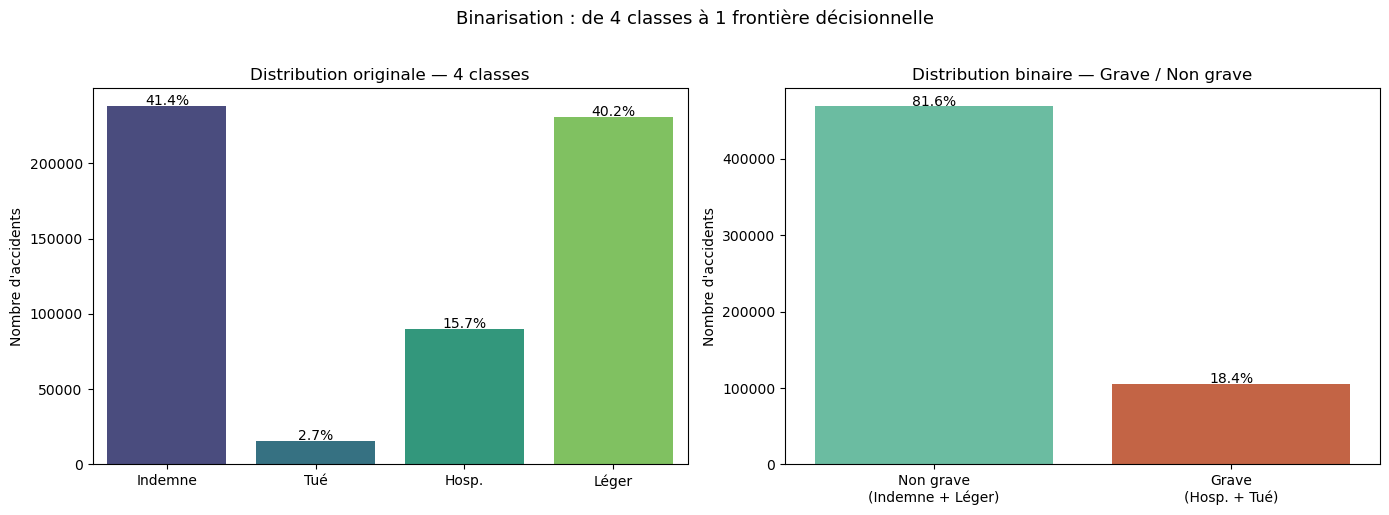

Déséquilibre binaire : 469,017 non graves / 105,655 graves
Ratio : 1 grave pour 4.4 non graves


In [1]:
# ============================================================
# Transformation du modèle de 4 classes à 2 classes (binaire)
# ============================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, roc_auc_score

# ============================================================
# 1. CHARGEMENT DES DONNÉES — compatible Jupyter + GitHub
# ============================================================

# Dossier où se trouve le notebook
BASE_DIR = os.getcwd()

# Chemin vers le dossier data/
folder = os.path.join(BASE_DIR, "data")

print("Lecture depuis :", folder)
print("Fichiers trouvés :", os.listdir(folder))

# Lecture des ZIP (pandas lit automatiquement le CSV à l'intérieur)
x_train = pd.read_csv(os.path.join(folder, "X_train.zip"))
x_test  = pd.read_csv(os.path.join(folder, "X_test.zip"))
y_train = pd.read_csv(os.path.join(folder, "y_train.zip"))
y_test  = pd.read_csv(os.path.join(folder, "y_test.zip"))

# ============================================================
# 2. REMAPPING MULTICLASSE
# ============================================================

mapping = {1.0: 0, 2.0: 1, 3.0: 2, 4.0: 3}
y_train_mapped = y_train.iloc[:, 0].map(mapping)
y_test_mapped = y_test.iloc[:, 0].map(mapping)

# ============================================================
# 3. BINARISATION — train ET test séparément (pas de leakage)
# ============================================================

def binariser(y):
    y = y.values.ravel()
    return np.where(np.isin(y, [1, 4]), 0, 1)
    # 0 = non grave : Indemne (1) + Léger (4)
    # 1 = grave     : Hospitalisé (3) + Tué (2)

y_train_bin = binariser(y_train.iloc[:, 0])
y_test_bin = binariser(y_test.iloc[:, 0])

# ============================================================
# 4. VISUALISATION COMPARÉE multi-classe vs binaire
# ============================================================

noms_multi = {1: "Indemne", 2: "Tué", 3: "Hosp.", 4: "Léger"}
noms_binaire = {0: "Non grave\n(Indemne + Léger)", 1: "Grave\n(Hosp. + Tué)"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution originale
counts_multi = pd.Series(y_train.iloc[:, 0]).value_counts().sort_index()
sns.barplot(
    x=[noms_multi[int(i)] for i in counts_multi.index],
    y=counts_multi.values,
    palette="viridis",
    ax=axes[0]
)
axes[0].set_title("Distribution originale — 4 classes")
axes[0].set_ylabel("Nombre d'accidents")
for i, v in enumerate(counts_multi.values):
    axes[0].text(i, v + 500, f"{v/len(y_train)*100:.1f}%", ha='center', fontsize=10)

# Distribution binaire
counts_bin = pd.Series(y_train_bin).value_counts().sort_index()
sns.barplot(
    x=[noms_binaire[int(i)] for i in counts_bin.index],
    y=counts_bin.values,
    palette=["#5DCAA5", "#D85A30"],
    ax=axes[1]
)
axes[1].set_title("Distribution binaire — Grave / Non grave")
axes[1].set_ylabel("Nombre d'accidents")
for i, v in enumerate(counts_bin.values):
    axes[1].text(i, v + 500, f"{v/len(y_train_bin)*100:.1f}%", ha='center', fontsize=10)

plt.suptitle("Binarisation : de 4 classes à 1 frontière décisionnelle", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"Déséquilibre binaire : {counts_bin[0]:,} non graves / {counts_bin[1]:,} graves")
print(f"Ratio : 1 grave pour {counts_bin[0]/counts_bin[1]:.1f} non graves")


C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



  Dummy (most_frequent)
  Accuracy        : 0.8171
  Macro F1        : 0.4497
  AUC-ROC         : 0.5000
  Recall 'grave'  : 0.0000

Classification Report :
              precision    recall  f1-score   support

   Non grave       0.82      1.00      0.90    117350
       Grave       0.00      0.00      0.00     26263

    accuracy                           0.82    143613
   macro avg       0.41      0.50      0.45    143613
weighted avg       0.67      0.82      0.73    143613



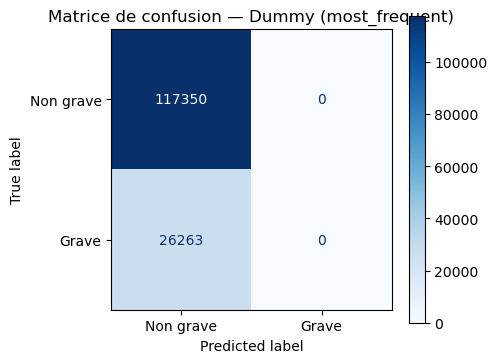

C:\Users\hp\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



  Régression logistique (balanced)
  Accuracy        : 0.7243
  Macro F1        : 0.6524
  AUC-ROC         : 0.8104
  Recall 'grave'  : 0.7366

Classification Report :
              precision    recall  f1-score   support

   Non grave       0.92      0.72      0.81    117350
       Grave       0.37      0.74      0.49     26263

    accuracy                           0.72    143613
   macro avg       0.65      0.73      0.65    143613
weighted avg       0.82      0.72      0.75    143613



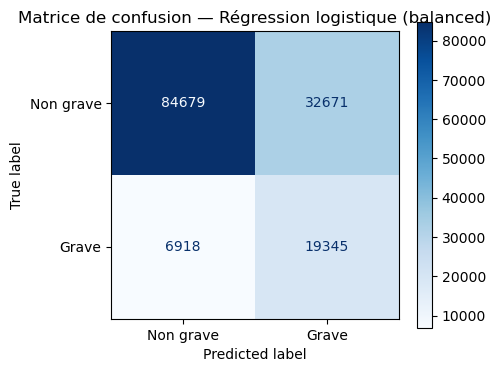


  Decision Tree (balanced)
  Accuracy        : 0.7266
  Macro F1        : 0.6653
  AUC-ROC         : 0.8412
  Recall 'grave'  : 0.8164

Classification Report :
              precision    recall  f1-score   support

   Non grave       0.95      0.71      0.81    117350
       Grave       0.38      0.82      0.52     26263

    accuracy                           0.73    143613
   macro avg       0.66      0.76      0.67    143613
weighted avg       0.84      0.73      0.76    143613



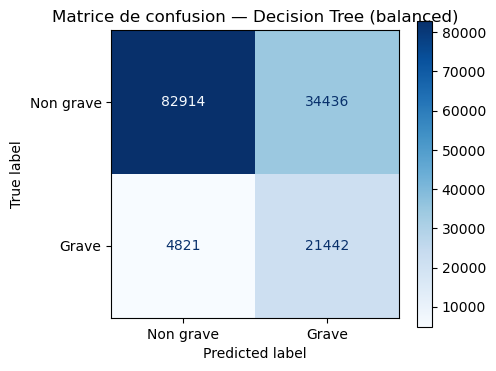


scale_pos_weight XGBoost : 4.44

  XGBoost pondéré
  Accuracy        : 0.7747
  Macro F1        : 0.7083
  AUC-ROC         : 0.8725
  Recall 'grave'  : 0.8139

Classification Report :
              precision    recall  f1-score   support

   Non grave       0.95      0.77      0.85    117350
       Grave       0.44      0.81      0.57     26263

    accuracy                           0.77    143613
   macro avg       0.69      0.79      0.71    143613
weighted avg       0.85      0.77      0.80    143613



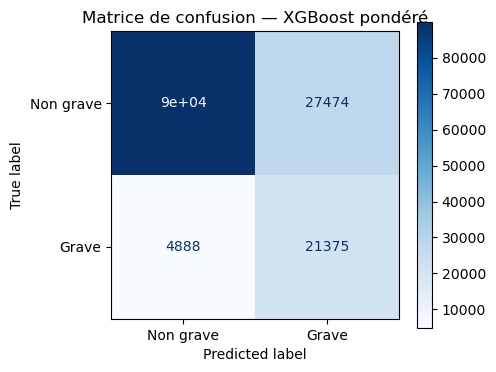


  Balanced Random Forest optimisé
  Accuracy        : 0.7508
  Macro F1        : 0.6909
  AUC-ROC         : 0.8703
  Recall 'grave'  : 0.8488

Classification Report :
              precision    recall  f1-score   support

   Non grave       0.96      0.73      0.83    117350
       Grave       0.41      0.85      0.55     26263

    accuracy                           0.75    143613
   macro avg       0.68      0.79      0.69    143613
weighted avg       0.86      0.75      0.78    143613



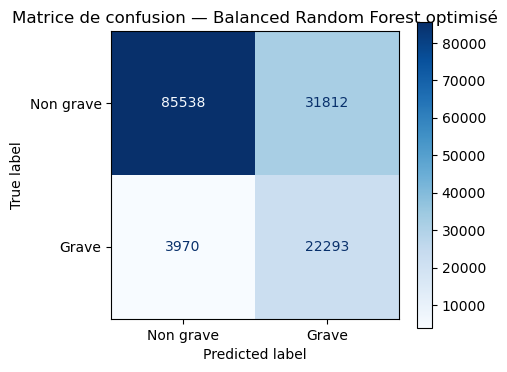


  SYNTHÈSE COMPARATIVE — Modèle binaire grave / non grave
                          Modèle  Accuracy  Macro F1    AUC  Recall grave
 Balanced Random Forest optimisé    0.7508    0.6909 0.8703        0.8488
        Decision Tree (balanced)    0.7266    0.6653 0.8412        0.8164
                 XGBoost pondéré    0.7747    0.7083 0.8725        0.8139
Régression logistique (balanced)    0.7243    0.6524 0.8104        0.7366
           Dummy (most_frequent)    0.8171    0.4497 0.5000        0.0000


C:\Users\hp\AppData\Local\Temp\ipykernel_2980\2483673454.py:159: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\hp\AppData\Local\Temp\ipykernel_2980\2483673454.py:159: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\hp\AppData\Local\Temp\ipykernel_2980\2483673454.py:159: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


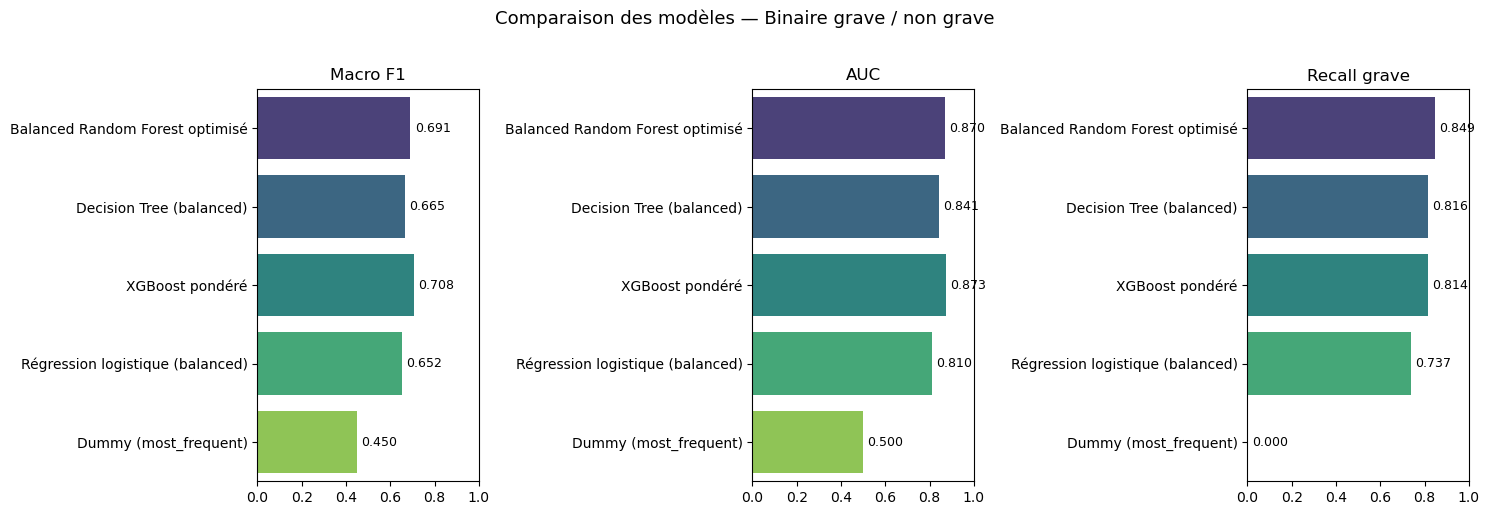

In [2]:
# =============================================================
# Analyse des performances des différents algorithmes
# =============================================================

# !pip install xgboost
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, roc_auc_score,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# =============================================================
# FONCTION D'ÉVALUATION UNIQUE — appelée pour chaque modèle
# =============================================================

def evaluer(nom, modele, x_tr, y_tr, x_te, y_te):
    modele.fit(x_tr, y_tr)
    y_pred = modele.predict(x_te)
    y_proba = modele.predict_proba(x_te)[:, 1]

    acc = accuracy_score(y_te, y_pred)
    f1_macro = f1_score(y_te, y_pred, average="macro")
    auc = roc_auc_score(y_te, y_proba)
    recall_grave = classification_report(
        y_te, y_pred, output_dict=True
    )["1"]["recall"]

    print(f"\n{'='*55}")
    print(f"  {nom}")
    print(f"{'='*55}")
    print(f"  Accuracy        : {acc:.4f}")
    print(f"  Macro F1        : {f1_macro:.4f}")
    print(f"  AUC-ROC         : {auc:.4f}")
    print(f"  Recall 'grave'  : {recall_grave:.4f}")
    print("\nClassification Report :")
    print(classification_report(
        y_te, y_pred,
        target_names=["Non grave", "Grave"],
        zero_division=0
    ))

    # Matrice de confusion
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_te, y_pred,
        display_labels=["Non grave", "Grave"],
        cmap="Blues", ax=ax
    )
    ax.set_title(f"Matrice de confusion — {nom}")
    plt.tight_layout()
    plt.show()

    return {
        "Modèle": nom,
        "Accuracy": round(acc, 4),
        "Macro F1": round(f1_macro, 4),
        "AUC": round(auc, 4),
        "Recall grave": round(recall_grave, 4)
    }

# =============================================================
# 1. DUMMY — plancher de référence
# =============================================================

r1 = evaluer(
    "Dummy (most_frequent)",
    DummyClassifier(strategy="most_frequent"),
    x_train, y_train_bin, x_test, y_test_bin
)

# =============================================================
# 2. RÉGRESSION LOGISTIQUE
# =============================================================

r2 = evaluer(
    "Régression logistique (balanced)",
    LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42),
    x_train, y_train_bin, x_test, y_test_bin
)

# =============================================================
# 3. DECISION TREE
# =============================================================

r3 = evaluer(
    "Decision Tree (balanced)",
    DecisionTreeClassifier(class_weight="balanced", max_depth=10, random_state=42),
    x_train, y_train_bin, x_test, y_test_bin
)

# =============================================================
# 4. XGBOOST — poids calculé automatiquement
# =============================================================

n_neg = (y_train_bin == 0).sum()
n_pos = (y_train_bin == 1).sum()
scale = n_neg / n_pos
print(f"\nscale_pos_weight XGBoost : {scale:.2f}")

r4 = evaluer(
    "XGBoost pondéré",
    XGBClassifier(
        n_estimators=300,
        max_depth=8,
        learning_rate=0.1,
        subsample=1.0,
        colsample_bytree=0.7,
        min_child_weight=5,
        scale_pos_weight=scale,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ),
    x_train, y_train_bin, x_test, y_test_bin
)

# =============================================================
# 5. BALANCED RANDOM FOREST — modèle recommandé
# =============================================================

r5 = evaluer(
    "Balanced Random Forest optimisé",
    BalancedRandomForestClassifier(
        n_estimators=300,
        max_depth=20,
        min_samples_split=2,
        sampling_strategy="not minority",
        random_state=42,
        n_jobs=-1
    ),
    x_train, y_train_bin, x_test, y_test_bin
)

# =============================================================
# 6. TABLEAU DE SYNTHÈSE COMPARATIF
# =============================================================

synthese = pd.DataFrame([r1, r2, r3, r4, r5])
synthese = synthese.sort_values("Recall grave", ascending=False)

print("\n" + "="*60)
print("  SYNTHÈSE COMPARATIVE — Modèle binaire grave / non grave")
print("="*60)
print(synthese.to_string(index=False))

# Visualisation synthèse
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metriques = ["Macro F1", "AUC", "Recall grave"]

for ax, metrique in zip(axes, metriques):
    sns.barplot(
        data=synthese, x=metrique, y="Modèle",
        palette="viridis", ax=ax
    )
    ax.set_xlim(0, 1)
    ax.set_title(metrique)
    ax.set_xlabel("")
    ax.set_ylabel("")
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9)

plt.suptitle("Comparaison des modèles — Binaire grave / non grave", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


Dossier utilisé : C:\Users\hp\Documents\Projet_accidents\data
Contenu : ['accidents_France_encoded.zip', 'accidents_France_raw.zip', 'X_test.zip', 'X_train.zip', 'y_test.zip', 'y_train.zip']

=== SYNTHÈSE — Modèle grave / non grave ===
                         Modèle  Accuracy  Macro F1    AUC  Recall grave
Balanced Random Forest optimisé    0.7508    0.6909 0.8703        0.8488

=== Classification hospitalisé vs tué ===
              precision    recall  f1-score   support

 Hospitalisé       0.90      0.72      0.80     22365
         Tué       0.25      0.56      0.35      3898

    accuracy                           0.69     26263
   macro avg       0.58      0.64      0.57     26263
weighted avg       0.81      0.69      0.73     26263



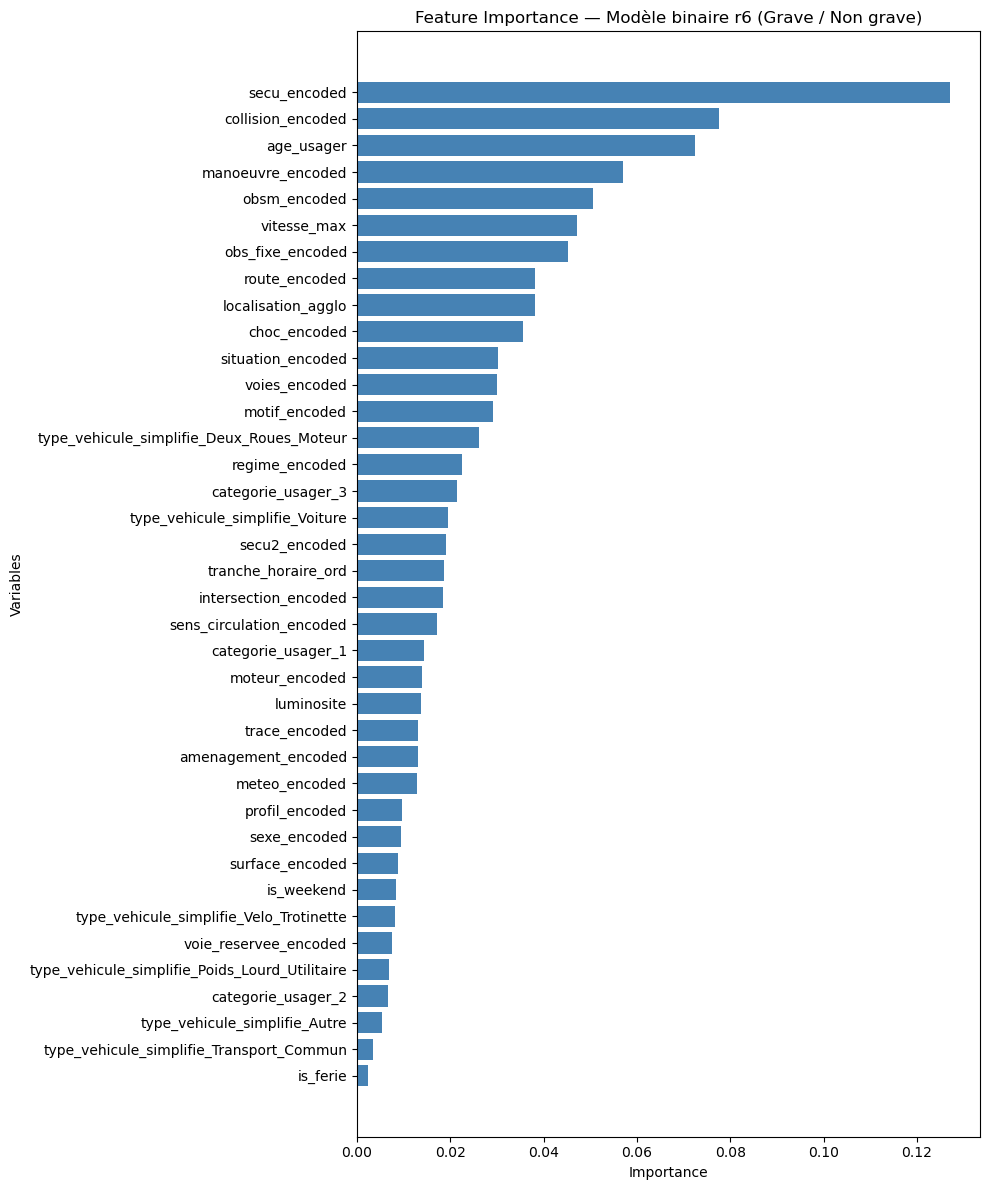


=== Feature Importance — Modèle binaire r6 ===
                                       feature  importance
                                  secu_encoded    0.127175
                             collision_encoded    0.077631
                                    age_usager    0.072487
                             manoeuvre_encoded    0.057056
                                  obsm_encoded    0.050697
                                   vitesse_max    0.047255
                              obs_fixe_encoded    0.045328
                                 route_encoded    0.038213
                            localisation_agglo    0.038198
                                  choc_encoded    0.035506
                             situation_encoded    0.030147
                                 voies_encoded    0.029992
                                 motif_encoded    0.029125
     type_vehicule_simplifie_Deux_Roues_Moteur    0.026108
                                regime_encoded    0.022580
        

In [3]:
# ===============================================================================
# Code complet pour binarisartion + BRF (modèle r6) + classification tué / graves
# ===============================================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report
)

from imblearn.ensemble import BalancedRandomForestClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

# =============================================================
# 1. CHARGEMENT DES DONNÉES — robuste, portable, ZIP + GitHub local
# =============================================================

BASE_DIR = os.getcwd()
folder = os.path.join(BASE_DIR, "data")

print("Dossier utilisé :", folder)
print("Contenu :", os.listdir(folder))

x_train = pd.read_csv(os.path.join(folder, "X_train.zip"))
x_test  = pd.read_csv(os.path.join(folder, "X_test.zip"))
y_train = pd.read_csv(os.path.join(folder, "y_train.zip"))
y_test  = pd.read_csv(os.path.join(folder, "y_test.zip"))

# =============================================================
# 2. NETTOYAGE 
# =============================================================

def nettoyer_cible(y):
    col = y.iloc[:,0]
    col = col.astype(str).str.strip().replace("", np.nan)
    col = col.astype(float).astype("Int64")
    return col

y_train_clean = nettoyer_cible(y_train)
y_test_clean  = nettoyer_cible(y_test)

mapping = {1:0, 2:1, 3:2, 4:3}
y_train_mapped = y_train_clean.map(mapping)
y_test_mapped  = y_test_clean.map(mapping)

# =============================================================
# 3. BINARISATION 
# =============================================================

def binariser(y):
    y = y.values.ravel()
    return np.where(np.isin(y, [1, 4]), 0, 1)

y_train_bin = binariser(y_train_clean)
y_test_bin  = binariser(y_test_clean)

# =============================================================
# 4. ALIGNEMENT DES INDEX
# =============================================================

y_train_mapped.index = x_train.index
y_test_mapped.index  = x_test.index
y_train_clean.index  = x_train.index
y_test_clean.index   = x_test.index

# =============================================================
# 5. FONCTION D'ÉVALUATION
# =============================================================

def evaluer(nom, modele, x_tr, y_tr, x_te, y_te):
    modele.fit(x_tr, y_tr)
    y_pred = modele.predict(x_te)
    y_proba = modele.predict_proba(x_te)[:, 1]

    acc = accuracy_score(y_te, y_pred)
    f1_macro = f1_score(y_te, y_pred, average="macro")
    auc = roc_auc_score(y_te, y_proba)
    recall_grave = classification_report(
        y_te, y_pred, output_dict=True
    )["1"]["recall"]

    return {
        "Modèle": nom,
        "Accuracy": round(acc, 4),
        "Macro F1": round(f1_macro, 4),
        "AUC": round(auc, 4),
        "Recall grave": round(recall_grave, 4)
    }, modele

# =============================================================
# 6. MODÈLE BINAIRE r6 — Balanced Random Forest
# =============================================================

r6, modele_r6 = evaluer(
    "Balanced Random Forest optimisé",
    BalancedRandomForestClassifier(
        n_estimators=300,
        max_depth=20,
        min_samples_split=2,
        sampling_strategy=1.0,
        random_state=42,
        n_jobs=-1
    ),
    x_train, y_train_bin, x_test, y_test_bin
)

print("\n=== SYNTHÈSE — Modèle grave / non grave ===")
print(pd.DataFrame([r6]).to_string(index=False))

# =============================================================
# 7. MODÈLE HOSPITALISÉ (3) vs TUÉ (2)
# =============================================================

mask_train_graves = y_train_clean.isin([2,3])
mask_test_graves  = y_test_clean.isin([2,3])

train_graves = x_train.loc[mask_train_graves]
test_graves  = x_test.loc[mask_test_graves]

y_train_graves = y_train_clean.loc[mask_train_graves].map({2:1, 3:0})
y_test_graves  = y_test_clean.loc[mask_test_graves].map({2:1, 3:0})

pipeline_grave = Pipeline([
    ("smote", SMOTE(sampling_strategy=0.8, random_state=42)),
    ("rf", RandomForestClassifier(
        n_estimators=300,
        max_depth=20,
        class_weight={0:1, 1:10},
        random_state=42,
        n_jobs=-1
    ))
])

pipeline_grave.fit(train_graves, y_train_graves)
y_pred_grave = pipeline_grave.predict(test_graves)

print("\n=== Classification hospitalisé vs tué ===")
print(classification_report(
    y_test_graves, y_pred_grave,
    target_names=["Hospitalisé", "Tué"],
    zero_division=0
))

# Importance des features du modèle binaire r6
importances_r6 = modele_r6.feature_importances_
features = x_train.columns

fi_r6 = pd.DataFrame({
    "feature": features,
    "importance": importances_r6
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 12))
plt.barh(fi_r6["feature"], fi_r6["importance"], color="steelblue")
plt.gca().invert_yaxis()
plt.title("Feature Importance — Modèle binaire r6 (Grave / Non grave)")
plt.xlabel("Importance")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()

print("\n=== Feature Importance — Modèle binaire r6 ===")
print(fi_r6.to_string(index=False))


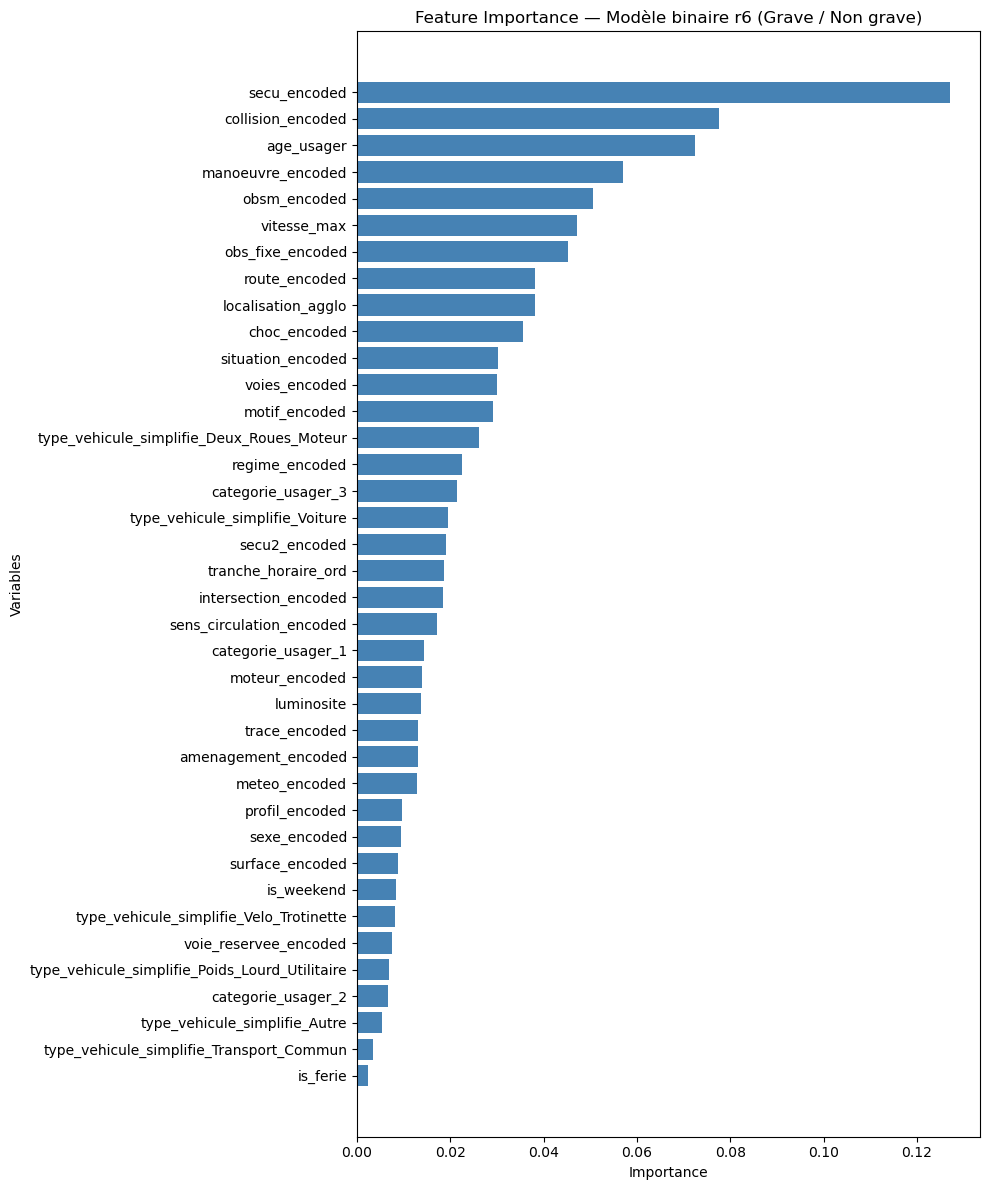


=== Feature Importance — Modèle binaire r6 ===
                                       feature  importance
                                  secu_encoded    0.127175
                             collision_encoded    0.077631
                                    age_usager    0.072487
                             manoeuvre_encoded    0.057056
                                  obsm_encoded    0.050697
                                   vitesse_max    0.047255
                              obs_fixe_encoded    0.045328
                                 route_encoded    0.038213
                            localisation_agglo    0.038198
                                  choc_encoded    0.035506
                             situation_encoded    0.030147
                                 voies_encoded    0.029992
                                 motif_encoded    0.029125
     type_vehicule_simplifie_Deux_Roues_Moteur    0.026108
                                regime_encoded    0.022580
        

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Importance des features du modèle binaire r6
importances_r6 = modele_r6.feature_importances_
features = x_train.columns

fi_r6 = pd.DataFrame({
    "feature": features,
    "importance": importances_r6
}).sort_values("importance", ascending=False)

# --- Histogramme ---
plt.figure(figsize=(10, 12))
plt.barh(fi_r6["feature"], fi_r6["importance"], color="steelblue")
plt.gca().invert_yaxis()
plt.title("Feature Importance — Modèle binaire r6 (Grave / Non grave)")
plt.xlabel("Importance")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()

# --- Listing propre ---
print("\n=== Feature Importance — Modèle binaire r6 ===")
print(fi_r6.to_string(index=False))

In [5]:
# =============================================================
# Fonction évaluation gravité
# =============================================================

def predict_gravite(df):
    """
    df : DataFrame contenant les mêmes colonnes que X_train
    Retourne : gravité binaire + gravité détaillée si grave
    """

    # 1. Prédiction grave / non grave
    proba_grave = modele_r6.predict_proba(df)[:, 1]
    pred_grave = (proba_grave >= 0.5).astype(int)

    # 2. Initialisation du résultat
    resultats = []

    for i, is_grave in enumerate(pred_grave):

        if is_grave == 0:
            resultats.append({
                "gravite_binaire": "Non grave",
                "gravite_detaillee": "Indemne ou Léger"
            })

        else:
            # 3. Prédiction hospitalisé / tué
            ligne = df.iloc[[i]]  # garder DataFrame
            pred_ht = pipeline_grave.predict(ligne)[0]

            if pred_ht == 0:
                detail = "Hospitalisé"
            else:
                detail = "Tué"

            resultats.append({
                "gravite_binaire": "Grave",
                "gravite_detaillee": detail
            })

    return pd.DataFrame(resultats)

In [21]:
import os
import pandas as pd
import numpy as np

# Dossiers compatibles GitHub
BASE_DIR = os.getcwd()
OUTPUT_DIR = os.path.join(BASE_DIR, "outputs")

# Charger X_train pour récupérer l'ordre exact des colonnes
X_train = pd.read_csv(os.path.join(OUTPUT_DIR, "X_train.csv"))

# ============================
# 1. MAPPINGS SIMPLIFIÉS
# ============================

SECU_MAPPING = {
    "Ceinture": 2.2,
    "Casque": 2.7,
    "Dispositif enfants": 2.9,
    "Gilet réfléchissant": 2.4,
    "Airbag (2RM/3RM)": 2.8,
    "Gants (2RM/3RM)": 2.5,
    "Gants + Airbag (2RM/3RM)": 2.9
}

COLLISION_MAPPING = {
    "Frontale": 2.7,
    "Latérale": 2.5,
    "Arrière": 2.3,
    "Multiple": 2.8,
    "Autre": 2.4
}

MANOEUVRE_MAPPING = {
    "Dépassement": 2.6,
    "Changement de voie": 2.5,
    "Virage": 2.4,
    "Freinage": 2.3,
    "Stationnement": 2.1,
    "Autre": 2.2
}

OBSM_MAPPING = {
    "Véhicule": 2.5,
    "Piéton": 2.7,
    "Cycliste": 2.6,
    "Animal": 2.3,
    "Objet": 2.2,
    "Autre": 2.4
}

# ============================
# 2. GÉNÉRATEUR D’ACCIDENT
# ============================

def generer_accident(secu, collision, age, manoeuvre, obstacle_mobile):
    """Génère un accident réaliste basé sur les 5 features principales."""

    accident = {
        # 5 paramètres principaux
        "secu_encoded": SECU_MAPPING[secu],
        "collision_encoded": COLLISION_MAPPING[collision],
        "age_usager": age,
        "manoeuvre_encoded": MANOEUVRE_MAPPING[manoeuvre],
        "obsm_encoded": OBSM_MAPPING[obstacle_mobile],

        # Variables importantes générées aléatoirement
        "vitesse_max": np.random.choice([30, 50, 70, 80, 90, 110, 130]),
        "obs_fixe_encoded": np.random.uniform(2.2, 2.8),
        "route_encoded": np.random.uniform(2.2, 2.8),
        "localisation_agglo": np.random.choice([0, 1]),
        "choc_encoded": np.random.uniform(2.2, 2.8),
        "situation_encoded": np.random.uniform(2.2, 2.8),
        "voies_encoded": np.random.uniform(2.2, 2.8),
        "motif_encoded": np.random.uniform(2.2, 2.8),
        "secu2_encoded": np.random.uniform(2.2, 2.8),
        "regime_encoded": np.random.uniform(2.2, 2.8),
        "tranche_horaire_ord": np.random.choice([1, 2, 3, 4]),
        "moteur_encoded": np.random.uniform(2.2, 2.8),
        "intersection_encoded": np.random.uniform(2.2, 2.8),
        "sens_circulation_encoded": np.random.uniform(2.2, 2.8),
        "luminosite": np.random.choice([0, 1]),
        "meteo_encoded": np.random.uniform(2.2, 2.8),
        "trace_encoded": np.random.uniform(2.2, 2.8),
        "amenagement_encoded": np.random.uniform(2.2, 2.8),
        "profil_encoded": np.random.uniform(2.2, 2.8),
        "surface_encoded": np.random.uniform(2.2, 2.8),
        "is_weekend": np.random.choice([0, 1]),
        "voie_reservee_encoded": np.random.uniform(2.2, 2.8),
        "sexe_encoded": np.random.choice([0, 1]),
        "is_ferie": np.random.choice([0, 1]),

        # One-Hot Encoding : choix aléatoire
        "categorie_usager_1": np.random.choice([0, 1]),
        "categorie_usager_2": np.random.choice([0, 1]),
        "categorie_usager_3": np.random.choice([0, 1]),

        "type_vehicule_simplifie_Voiture": np.random.choice([0, 1]),
        "type_vehicule_simplifie_Deux_Roues_Moteur": np.random.choice([0, 1]),
        "type_vehicule_simplifie_Velo_Trotinette": np.random.choice([0, 1]),
        "type_vehicule_simplifie_Poids_Lourd_Utilitaire": np.random.choice([0, 1]),
        "type_vehicule_simplifie_Transport_Commun": np.random.choice([0, 1]),
        "type_vehicule_simplifie_Autre": np.random.choice([0, 1])
    }

    # Correction : une seule catégorie doit être à 1
    cats = ["categorie_usager_1", "categorie_usager_2", "categorie_usager_3"]
    chosen = np.random.choice(cats)
    for c in cats:
        accident[c] = 1 if c == chosen else 0

    vehs = [
        "type_vehicule_simplifie_Voiture",
        "type_vehicule_simplifie_Deux_Roues_Moteur",
        "type_vehicule_simplifie_Velo_Trotinette",
        "type_vehicule_simplifie_Poids_Lourd_Utilitaire",
        "type_vehicule_simplifie_Transport_Commun",
        "type_vehicule_simplifie_Autre"
    ]
    chosen_v = np.random.choice(vehs)
    for v in vehs:
        accident[v] = 1 if v == chosen_v else 0

    # Conversion en DataFrame
    df_accident = pd.DataFrame([accident])

    # Réordonner selon X_train
    df_accident = df_accident[X_train.columns]

    return df_accident

# ============================
# 3. EXEMPLE D’UTILISATION
# ============================

accident = generer_accident(
    secu="Gants + Airbag (2RM/3RM)",
    collision="Frontale",
    age=40,
    manoeuvre="Dépassement",
    obstacle_mobile="Cycliste"
)

predict_gravite(accident)


,gravite_binaire,gravite_detaillee
0,Grave,Hospitalisé
